# Evaluación 2 · Sección 2 — Estadística descriptiva

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM · INF074H

**Integrantes:** Daniela Contreras · Emanuel Nicklichen

**Proyecto:** *Quedar fuera teniendo puntaje* — revisión del proceso de Admisión a la Educación Superior 2026.

Continuación de `05_evaluacion2_seccion1_calidad.ipynb`. Se aplican tendencia central, dispersión, forma (asimetría) y detección de atípicos (boxplot/IQR) a las variables relevantes declaradas en la formulación.

## 2.0 Nota metodológica: factores de expansión

Las cinco tablas del proyecto son el **registro administrativo completo** del proceso de admisión 2026 (320.087 inscritos, no una muestra de ellos). No existen factores de expansión ni pesos de muestreo que aplicar — cada fila ya representa exactamente a un estudiante o una preferencia real, con ponderación 1. Se deja esto declarado explícitamente para no dar la impresión de que se omitió un paso.

## 2.1 Carga y recordatorio del tratamiento de ceros

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw"

carpetas = {
    "Inscritos":       "PAES-2026-Inscritos-Puntajes",
    "Socioeconomico":  "PAES-2026-Socioeconomicos",
    "Postulantes":      "PAES-2026-Postulantes",
    "Matricula":        "PAES-2026-Matricula",
    "Oferta":           "PAES-2026-Oferta-Definitiva-Programas",
}

# Mismo patron robusto de 05_evaluacion2_seccion1_calidad.ipynb: glob() en vez
# de nombre de archivo fijo, para no repetir el FileNotFoundError ya resuelto.
bases = {}
for nombre, carpeta in carpetas.items():
    archivo = list((RAW_DIR / carpeta).glob("*.csv"))[0]
    if nombre == "Oferta":
        bases[nombre] = pd.read_csv(archivo, sep=",", decimal=".")
    else:
        bases[nombre] = pd.read_csv(archivo, sep=";", decimal=",", low_memory=False)

A, B, C, D, O = bases["Inscritos"], bases["Socioeconomico"], bases["Postulantes"], bases["Matricula"], bases["Oferta"]
n = len(A)

En `05_evaluacion2_seccion1_calidad.ipynb` se documentó que `CLEC_MAX`, `MATE1_MAX`, `MATE2_MAX`, `HCSOC_MAX` y `CIEN_MAX` usan **0 como centinela** de "no rindió la prueba", no como puntaje real — confirmado con evidencia independiente (cuadernillo asignado y puntajes de procesos anteriores) para las cinco.

**Decisión de equipo para esta sección:** para las cinco pruebas se reportan **dos versiones** de cada estadístico — con toda la muestra (incluye el centinela, permite ver qué proporción no rindió) y solo entre quienes obtuvieron un puntaje real (`> 0`). Esta exclusión aplica **únicamente a los cálculos de esta sección** (para no distorsionar media, forma y atípicos); el resto del proyecto (embudo de admisión, puntaje ponderado) conserva todos los casos, porque un estudiante que no rindió igual participa del proceso de postulación.

`PTJE_NEM` y `PTJE_RANKING` también tienen ceros (1,91%), pero **no se excluyen**: a diferencia de una prueba PAES, la nota de enseñanza media no depende de "presentarse a rendir" — un cero ahí es más probablemente un registro incompleto del establecimiento, y tratarlo igual que un "no rindió" sería una decisión sin sustento. Se reporta el porcentaje, no se retira.

## 2.2 Estadística descriptiva: pruebas de puntaje (CLEC_MAX, MATE1_MAX, MATE2_MAX, HCSOC_MAX, CIEN_MAX)

In [2]:
# Para cada prueba, calculamos los mismos 5 estadisticos en dos poblaciones:
# "todos" (incluye el centinela 0) y "validos" (solo quienes rindieron, > 0).
# stats.skew mide la asimetria: 0 = simetrica, negativo = cola a la izquierda,
# positivo = cola a la derecha.
pruebas = ["CLEC_MAX", "MATE1_MAX", "MATE2_MAX", "HCSOC_MAX", "CIEN_MAX"]

resumen_pruebas = []
for col in pruebas:
    todos = A[col]
    validos = A.loc[A[col] > 0, col]
    resumen_pruebas.append({
        "Prueba": col,
        "% rindio": round(len(validos) / n * 100, 1),
        "Media (todos)": round(todos.mean(), 1),
        "Media (validos)": round(validos.mean(), 1),
        "Mediana (validos)": round(validos.median(), 1),
        "Std (validos)": round(validos.std(), 1),
        "Asimetria (todos)": round(stats.skew(todos), 3),
        "Asimetria (validos)": round(stats.skew(validos), 3),
    })

resumen_pruebas = pd.DataFrame(resumen_pruebas)
resumen_pruebas

,Prueba,% rindio,Media (todos),Media (validos),Mediana (validos),Std (validos),Asimetria (todos),Asimetria (validos)
0,CLEC_MAX,86.5,532.5,615.4,605.0,125.7,-1.157,0.207
1,MATE1_MAX,85.4,544.9,638.2,609.0,149.6,-0.859,0.602
2,MATE2_MAX,39.5,168.4,426.9,409.0,90.6,0.677,1.431
3,HCSOC_MAX,46.3,236.8,511.8,488.0,130.4,0.499,0.838
4,CIEN_MAX,61.4,293.7,478.5,439.0,122.0,0.030,1.185


### La asimetría, explicada con nuestros propios datos

La asimetría (*skewness*) mide qué tan lejos está una distribución de ser simétrica, y hacia qué lado se estira la cola:

- **Negativa** (cola a la izquierda): la mayoría de los datos está en valores altos, con una cola de valores bajos que "jala" el promedio hacia abajo.
- **Positiva** (cola a la derecha): la mayoría está en valores bajos, con una cola de valores altos.
- **Cerca de 0**: distribución razonablemente simétrica.

Nuestros propios datos muestran el efecto de forma muy clara: `CLEC_MAX` con **todos** los casos tiene asimetría **-1,157** (fuertemente negativa) — porque el 13,5% en cero actúa como una cola de valores bajos que se aleja del resto. Al quedarnos **solo con quienes rindieron**, la asimetría cambia a **+0,207**, casi simétrica: el centinela era el que producía la forma "rara", no el desempeño real de los estudiantes. Es la misma razón por la que la media (todos) de `CLEC_MAX` es 532,5 pero sube a 615,4 entre quienes sí rindieron — el 0 no solo distorsiona la forma, también arrastra el promedio hacia abajo.

### Atípicos (boxplot / IQR): se marcan, no se eliminan

In [3]:
# Para cada prueba (solo entre quienes rindieron), calculamos los limites de
# Tukey: todo lo que cae fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] se marca como
# atipico. No se elimina ninguna fila -- la pauta pide identificarlos, la
# decision de tratarlos queda para la etapa de modelado.
atipicos_resumen = []
for col in pruebas:
    validos = A.loc[A[col] > 0, col]
    q1, q3 = validos.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_atipicos = ((validos < lim_inf) | (validos > lim_sup)).sum()
    atipicos_resumen.append({
        "Prueba": col, "Q1": q1, "Q3": q3, "IQR": round(iqr,1),
        "Limite inferior": round(lim_inf,1), "Limite superior": round(lim_sup,1),
        "Atipicos": n_atipicos, "% de validos": round(n_atipicos/len(validos)*100, 2)
    })
pd.DataFrame(atipicos_resumen)

,Prueba,Q1,Q3,IQR,Limite inferior,Limite superior,Atipicos,% de validos
0,CLEC_MAX,511.0,699.0,188.0,229.0,981.0,207,0.07
1,MATE1_MAX,516.0,723.0,207.0,205.5,1033.5,31,0.01
2,MATE2_MAX,366.0,467.0,101.0,214.5,618.5,5529,4.38
3,HCSOC_MAX,406.0,593.0,187.0,125.5,873.5,2022,1.37
4,CIEN_MAX,396.0,533.0,137.0,190.5,738.5,10254,5.22


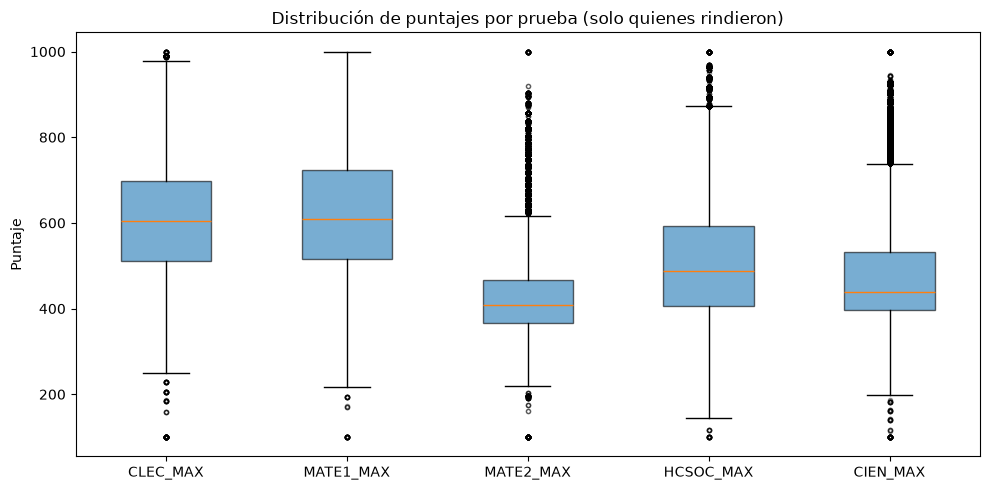

In [4]:
# Boxplot comparativo de las 5 pruebas, solo entre quienes rindieron
datos_boxplot = [A.loc[A[c] > 0, c] for c in pruebas]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(datos_boxplot, tick_labels=pruebas, patch_artist=True,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
for patch in bp["boxes"]:
    patch.set_facecolor("#1f77b4")
    patch.set_alpha(0.6)
ax.set_ylabel("Puntaje")
ax.set_title("Distribución de puntajes por prueba (solo quienes rindieron)")
plt.tight_layout()
plt.show()

**Decisión documentada:** las pruebas optativas (`MATE2_MAX`, `CIEN_MAX`) concentran muchos más atípicos (4,38% y 5,22%) que las obligatorias (`CLEC_MAX` 0,07%, `MATE1_MAX` 0,01%) — visible en el boxplot como una nube de puntos sobre la caja. Es coherente con ser una subpoblación más pequeña y autoseleccionada (quienes rinden Ciencias o Historia suelen orientarse a carreras específicas, con puntajes más dispersos en el extremo alto). Estos atípicos **no se eliminan**: son puntajes reales de estudiantes reales. Se marcan aquí; la decisión de excluirlos o no de un modelo posterior se tomará en esa etapa, con el criterio explícito de si distorsionan o no el objetivo específico de ese modelo.

## 2.3 PTJE_NEM y PTJE_RANKING (sin excluir ceros)

In [5]:
# A diferencia de las pruebas PAES, aqui NO excluimos los ceros (ver 2.1):
# no hay evidencia de que signifiquen "no rindio", asi que se reportan tal cual.
for col in ["PTJE_NEM", "PTJE_RANKING"]:
    s = A[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    atipicos = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()
    print(f"--- {col} ---")
    print(f"Media: {s.mean():.1f}  Mediana: {s.median():.1f}  Std: {s.std():.1f}  Asimetria: {stats.skew(s):.3f}")
    print(f"Q1: {q1:.1f}  Q3: {q3:.1f}  Atipicos (IQR): {atipicos} ({atipicos/n*100:.2f}%)")
    print(f"Ceros: {(s==0).sum()} ({(s==0).sum()/n*100:.2f}%) -- se reportan, no se excluyen")
    print()

--- PTJE_NEM ---
Media: 696.6  Mediana: 713.0  Std: 175.6  Asimetria: -1.168
Q1: 594.0  Q3: 823.0  Atipicos (IQR): 6214 (1.94%)
Ceros: 6129 (1.91%) -- se reportan, no se excluyen

--- PTJE_RANKING ---
Media: 708.9  Mediana: 722.0  Std: 185.1  Asimetria: -1.018
Q1: 595.0  Q3: 845.0  Atipicos (IQR): 6165 (1.93%)
Ceros: 6129 (1.91%) -- se reportan, no se excluyen



## 2.4 PTJE_PREF (Postulantes)

In [6]:
# PTJE_PREF llega como texto con coma decimal (ej. "666,100"). Dos pasos:
# 1) reemplazar la coma por punto, 2) convertir a numero. El espacio en
# blanco (7.78%, documentado en Seccion 1) queda como NaN tras la conversion
# y se excluye con dropna() -- es la misma exclusion ya documentada, no una nueva.
ptje_pref = pd.to_numeric(C["PTJE_PREF"].str.replace(",", "."), errors="coerce")
ptje_valido = ptje_pref.dropna()

print(f"Validos: {len(ptje_valido)} ({len(ptje_valido)/len(C)*100:.2f}% de {len(C)})")
print(f"Media: {ptje_valido.mean():.1f}  Mediana: {ptje_valido.median():.1f}  Std: {ptje_valido.std():.1f}  Asimetria: {stats.skew(ptje_valido):.3f}")

q1, q3 = ptje_valido.quantile([0.25, 0.75])
iqr = q3 - q1
atipicos = ((ptje_valido < q1-1.5*iqr) | (ptje_valido > q3+1.5*iqr)).sum()
print(f"Q1: {q1:.1f}  Q3: {q3:.1f}  Atipicos (IQR): {atipicos} ({atipicos/len(ptje_valido)*100:.2f}%)")

Validos: 1562222 (92.22% de 1694081)
Media: 705.9  Mediana: 695.7  Std: 120.6  Asimetria: 0.442
Q1: 616.8  Q3: 784.7  Atipicos (IQR): 15133 (0.97%)


## 2.5 Numéricas discretas: VAC_1ER y ORDEN_PREF

In [7]:
# VAC_1ER: mismo bloque de estadisticos que las variables anteriores
s = O["VAC_1ER"]
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
atipicos = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()
print("--- VAC_1ER (vacantes por programa) ---")
print(f"Media: {s.mean():.1f}  Mediana: {s.median():.1f}  Std: {s.std():.1f}  Asimetria: {stats.skew(s):.3f}")
print(f"Min: {s.min()}  Max: {s.max()}")
print(f"Atipicos (IQR): {atipicos} ({atipicos/len(O)*100:.2f}%)")
print()
print("Programas con mas vacantes:")
print(O.nlargest(3, "VAC_1ER")[["CARRERA","UNIVERSIDAD","VAC_1ER"]].to_string(index=False))

--- VAC_1ER (vacantes por programa) ---
Media: 67.1  Mediana: 50.0  Std: 58.7  Asimetria: 3.636
Min: 1  Max: 710
Atipicos (IQR): 145 (6.74%)

Programas con mas vacantes:
                           CARRERA                              UNIVERSIDAD  VAC_1ER
INGENIERÍA Y CIENCIAS - PLAN COMÚN                     UNIVERSIDAD DE CHILE      710
                        INGENIERÍA PONTIFICIA UNIVERSIDAD CATOLICA DE CHILE      650
 INGENIERIA COMERCIAL (LAS CONDES)                 UNIVERSIDAD ANDRES BELLO      500


Asimetría de 3,64 es alta — la mayoría de los programas tiene entre 35 y 80 vacantes, pero unos pocos (Ingeniería en universidades grandes) superan las 500. Tratamos la cola larga con escala logarítmica, tal como pide la pauta:

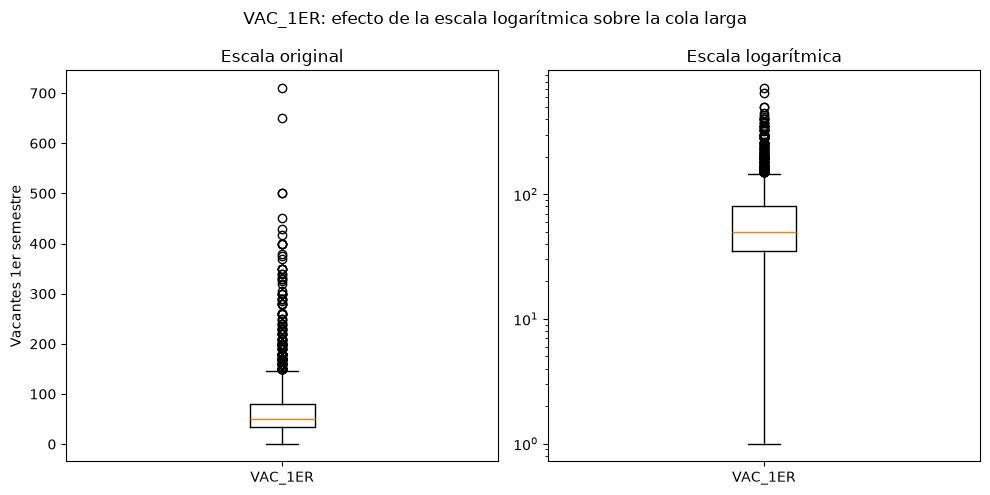

In [8]:
# Mismo boxplot en dos paneles: escala original vs logaritmica,
# para tratar la cola larga tal como pide la pauta (criterio 4).
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(O["VAC_1ER"], tick_labels=["VAC_1ER"])
axes[0].set_title("Escala original")
axes[0].set_ylabel("Vacantes 1er semestre")

axes[1].boxplot(O["VAC_1ER"], tick_labels=["VAC_1ER"])
axes[1].set_yscale("log")  # comprime la cola larga para poder ver la caja central
axes[1].set_title("Escala logarítmica")

plt.suptitle("VAC_1ER: efecto de la escala logarítmica sobre la cola larga")
plt.tight_layout()
plt.show()

In [9]:
# ORDEN_PREF: numerica discreta acotada (1-20), sin nulos ni fuera de rango (Seccion 1)
s = C["ORDEN_PREF"]
print("--- ORDEN_PREF (posicion en la lista de preferencias) ---")
print(f"Media: {s.mean():.2f}  Mediana: {s.median():.1f}  Std: {s.std():.2f}  Asimetria: {stats.skew(s):.3f}")
print(f"Min: {s.min()}  Max: {s.max()} (rango declarado: 1 a 20, sin excepciones -- confirmado en Seccion 1)")

--- ORDEN_PREF (posicion en la lista de preferencias) ---
Media: 6.01  Mediana: 5.0  Std: 4.60  Asimetria: 1.077
Min: 1  Max: 20 (rango declarado: 1 a 20, sin excepciones -- confirmado en Seccion 1)


Asimetría positiva moderada (1,08): la mayoría de los estudiantes concentra sus preferencias más "decididas" en las primeras posiciones (mediana en el puesto 5), con una cola de listas que sí llegan a usar las 20 posiciones completas.

## 2.6 INGRESO_PERCAPITA_GRUPO_FA (ordinal, excluyendo el código disfrazado)

In [10]:
# Documentado en Seccion 1: el codigo 99 = "prefiere no responder", no un decil real.
# Se excluye para esta distribucion, dejando explicito cuanto se pierde.
ing_valido = B.loc[B["INGRESO_PERCAPITA_GRUPO_FA"] != 99, "INGRESO_PERCAPITA_GRUPO_FA"]
n_excluido = (B["INGRESO_PERCAPITA_GRUPO_FA"] == 99).sum()

print(f"Validos: {len(ing_valido)} ({len(ing_valido)/len(B)*100:.2f}%)")
print(f"Excluidos (codigo 99): {n_excluido} ({n_excluido/len(B)*100:.2f}%)")
print()
print(ing_valido.value_counts().sort_index())

Validos: 231707 (72.39%)
Excluidos (codigo 99): 88380 (27.61%)

INGRESO_PERCAPITA_GRUPO_FA
1     44641
2     33590
3     23658
4     21701
5     17318
6     15915
7     25266
8     20715
9     14455
10    14448
Name: count, dtype: int64


El decil 1 (más bajo ingreso) concentra la mayor cantidad de casos (44.641) — casi el doble que cualquier otro decil individual. **Se deja explícito**: cualquier análisis posterior por nivel socioeconómico se hace sobre el 72,39% que sí respondió; el 27,61% restante no se imputa ni se supone, se excluye y se reporta.

## 2.7 Variables categóricas: tablas de frecuencia

Para variables categóricas no aplican media ni desviación estándar — el resumen adecuado es la tabla de frecuencia y su porcentaje.

In [11]:
# DEPENDENCIA: el codigo en blanco (fuera de dominio, Seccion 1) se muestra
# aparte, no se mezcla con los 6 codigos oficiales.
dep_map = {"1":"Corp. Municipal","2":"Municipal","3":"Part. Subvencionado",
           "4":"Part. Pagado","5":"Corp. Adm. Delegada","6":"SLEP"}
dep_clean = A["DEPENDENCIA"].astype(str).str.strip()
dep_freq = dep_clean.replace("", "Sin dato (fuera de dominio)").replace(dep_map).value_counts()
dep_pct = (dep_freq / n * 100).round(2)
pd.DataFrame({"Frecuencia": dep_freq, "%": dep_pct})

,Frecuencia,%
DEPENDENCIA,,
Part. Subvencionado,168231,52.56
Municipal,48543,15.17
Part. Pagado,35248,11.01
SLEP,34372,10.74
Corp. Municipal,19922,6.22
Corp. Adm. Delegada,10571,3.30
Sin dato (fuera de dominio),3200,1.00


In [12]:
# HABILITACION_POST: formula oficial encontrada en el diccionario (Seccion 1
# quedo con la version resumida de la formulacion; esta es la version exacta):
# 1 = promedio CLEC_MAX/MATE1_MAX >= 458 y ciencias o historia rendida
# 2 = promedio < 458 pero PORC_SUP_NOTAS = 10% y ciencias o historia rendida
# 3 = no cumple ni 1 ni 2
hab_freq = A["HABILITACION_POST"].map({1:"Habilitado",2:"No habilitado (excepcion notas)",3:"No habilitado"}).value_counts()
pd.DataFrame({"Frecuencia": hab_freq, "%": (hab_freq/n*100).round(2)})

,Frecuencia,%
HABILITACION_POST,,
Habilitado,241766,75.53
No habilitado,77708,24.28
No habilitado (excepcion notas),613,0.19


In [13]:
# RAMA_EDUCACIONAL: la formulacion declaraba solo H1-H2 y T1-T5 (6 categorias);
# el dato real trae H1-H4 y T1-T5 (9), mas los 463 nulos reales de Seccion 1.
rama_freq = A["RAMA_EDUCACIONAL"].value_counts(dropna=False)
pd.DataFrame({"Frecuencia": rama_freq, "%": (rama_freq/n*100).round(3)})

,Frecuencia,%
RAMA_EDUCACIONAL,,
H1,216909,67.766
T2,30721,9.598
T1,24819,7.754
T3,22147,6.919
H2,17760,5.548
T4,3820,1.193
H3,1993,0.623
H4,744,0.232
T5,711,0.222


In [14]:
# TIPO_PREF: via de admision de cada preferencia (Seccion 1 confirmo que
# junto a ORDEN_PREF forma la llave unica de cada fila de Postulantes)
tipo_freq = C["TIPO_PREF"].value_counts()
pd.DataFrame({"Frecuencia": tipo_freq, "%": (tipo_freq/len(C)*100).round(2)})

,Frecuencia,%
TIPO_PREF,,
REGULAR,1413512,83.44
PACE,111800,6.60
GENERO,87833,5.18
BEA,80936,4.78


In [15]:
# ESTADO_PREF tiene 18 codigos (Seccion 1); para una tabla de frecuencia
# legible se agrupan en 4 categorias segun el Anexo I oficial.
def agrupar_estado(codigo):
    if codigo in [24, 26]:
        return "Seleccionado"
    elif codigo == 25:
        return "Lista de espera"
    elif codigo in [9, 15, 17, 19, 20, 22, 23, 51, 52]:
        return "Anulada: no cumple requisito previo"
    else:
        return "Anulada: bajo puntaje de corte"

estado_freq = C["ESTADO_PREF"].apply(agrupar_estado).value_counts()
pd.DataFrame({"Frecuencia": estado_freq, "%": (estado_freq/len(C)*100).round(2)})

,Frecuencia,%
ESTADO_PREF,,
Seleccionado,1174407,69.32
Lista de espera,387815,22.89
Anulada: bajo puntaje de corte,79160,4.67
Anulada: no cumple requisito previo,52699,3.11


## Uso de Inteligencia Artificial

Se utilizó **Claude (Anthropic)** como asistente para el cálculo y verificación de los estadísticos descriptivos de este notebook, la generación de las visualizaciones (boxplots) y la redacción de las interpretaciones. Se utilizó además **ChatGPT** para el código de visualización original en `01_exploracion_datos.ipynb`, del cual se reutilizan convenciones de estilo. El diseño de la pregunta de investigación, las decisiones metodológicas (incluida la exclusión de centinelas descrita en 2.1) y la verificación final de cada hallazgo son del equipo; todas las cifras son reproducibles sobre las bases públicas declaradas.